**ML Project**

by Salah ud din

**Import Libraries: Begin by importing the necessary libraries for data manipulation, visualization, and machine learning. Common libraries include pandas, numpy, matplotlib, seaborn, and scikit-learn, among others.**

In [2]:
# Import Libraries
import pandas as pnds
import numpy as nmpy
import matplotlib.pyplot as pyplt
import seaborn as sbrn

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.inspection import permutation_importance

from pathlib import Path
!pip install xlrd>=2.0.1

**Load Data: Load the dataset into a pandas DataFrame. Ensure the data is loaded correctly and is in a format suitable for preprocessing.**

In [18]:
#downloaded the datafile locally to add to jupyter notebook
#when checking you can change the path to the location of the file on your local machine
#my path name had spaces in it so I used the raw string notation to avoid errors
#also make sure to have the xlrd package installed to read the excel file

path = Path(r"C:\Users\sa250048\OneDrive - Teradata Corporation\Desktop\ml-project\ml-project\CTG.xls")
df = pnds.read_excel(path,sheet_name="Raw Data")

df.head(10)



(2130, 40)


,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Variab10.txt,1996-12-01,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,1996-05-03,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,1996-05-03,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,1996-05-03,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
5,Fmcs_1.txt,1996-05-03,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
6,Fmcs_2.txt,1996-05-03,CTG0006.txt,0.0,953.0,134.0,134.0,1.0,0.0,10.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
7,Fmcs_2.txt,1996-05-03,CTG0007.txt,240.0,953.0,134.0,134.0,1.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
8,Hasc_1.txt,1995-02-22,CTG0008.txt,62.0,679.0,122.0,122.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0
9,Hasc_1.txt,1995-02-22,CTG0009.txt,120.0,779.0,122.0,122.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,3.0


**Data Preprocessing: Clean the data by handling missing values, encoding categorical variables, and scaling numerical features. Apply transformations as needed based on the type of data.**

In [27]:
print(df.shape)
# checking nulls
df.isnull().sum()[df.isnull().sum()>0]

(2130, 40)


FileName    4
Date        4
SegFile     4
b           4
e           4
LBE         4
LB          4
AC          4
FM          3
UC          3
ASTV        3
MSTV        3
ALTV        3
MLTV        3
DL          2
DS          2
DP          2
DR          2
Width       4
Min         4
Max         4
Nmax        4
Nzeros      4
Mode        4
Mean        4
Median      4
Variance    4
Tendency    4
A           4
B           4
C           4
D           4
E           4
AD          4
DE          4
LD          4
FS          4
SUSP        4
CLASS       4
NSP         4
dtype: int64

In [28]:
# checking nulls
df.dropna(how='all', inplace=True)


In [29]:
print(df.shape)
# checking nulls
df.isnull().sum()[df.isnull().sum()>0]

(2128, 40)


FileName    2
Date        2
SegFile     2
b           2
e           2
LBE         2
LB          2
AC          2
FM          1
UC          1
ASTV        1
MSTV        1
ALTV        1
MLTV        1
Width       2
Min         2
Max         2
Nmax        2
Nzeros      2
Mode        2
Mean        2
Median      2
Variance    2
Tendency    2
A           2
B           2
C           2
D           2
E           2
AD          2
DE          2
LD          2
FS          2
SUSP        2
CLASS       2
NSP         2
dtype: int64

In [30]:
df.dropna( inplace=True)

In [31]:
print(df.shape)
# checking nulls
df.isnull().sum()[df.isnull().sum()>0]

(2126, 40)


Series([], dtype: int64)

In [33]:
print(df.duplicated())
df.duplicated().sum()[df.duplicated().sum()>0]

1       False
2       False
3       False
4       False
5       False
        ...  
2122    False
2123    False
2124    False
2125    False
2126    False
Length: 2126, dtype: bool


array([], dtype=int64)

In [42]:
for col in df:
  print(f"{col} has {df[col].size} total values.")
  print(f"{col} has {df[col].nunique()} non-unique values.")
  print(f"{col} has unique values: {df[col].unique()} ")
  print()

FileName has 2126 total values.
FileName has 352 non-unique values.
FileName has unique values: <StringArray>
['Variab10.txt',   'Fmcs_1.txt',   'Fmcs_2.txt',   'Hasc_1.txt',
    'Hasc3.txt', 'Mcslrc_1.txt', 'Mcslrc_2.txt', 'Mcslrc_3.txt',
 'Mcslrc_4.txt',  'Mmmfm_1.txt',
 ...
 'S8001034.dsp', 'S8001035.dsp', 'S8001036.dsp', 'S8001037.dsp',
 'S8001038.dsp', 'S8001041.dsp', 'S8001042.dsp', 'S8001043.dsp',
 'S8001044.dsp', 'S8001045.dsp']
Length: 352, dtype: str 

Date has 2126 total values.
Date has 48 non-unique values.
Date has unique values: <DatetimeArray>
['1996-12-01 00:00:00', '1996-05-03 00:00:00', '1995-02-22 00:00:00',
 '1995-01-08 00:00:00', '1996-05-01 00:00:00', '1996-03-19 00:00:00',
 '1996-05-02 00:00:00', '1980-01-04 00:00:00', '1996-05-06 00:00:00',
 '1996-04-27 00:00:00', '1996-12-23 00:00:00', '1996-02-20 00:00:00',
 '1998-04-06 00:00:00', '1996-03-13 00:00:00', '1995-03-10 00:00:00',
 '1996-07-16 00:00:00', '1996-07-17 00:00:00', '1996-07-18 00:00:00',
 '1996-08-16 0

In [34]:
df.dtypes

FileName               str
Date        datetime64[us]
SegFile                str
b                  float64
e                  float64
LBE                float64
LB                 float64
AC                 float64
FM                 float64
UC                 float64
ASTV               float64
MSTV               float64
ALTV               float64
MLTV               float64
DL                 float64
DS                 float64
DP                 float64
DR                 float64
Width              float64
Min                float64
Max                float64
Nmax               float64
Nzeros             float64
Mode               float64
Mean               float64
Median             float64
Variance           float64
Tendency           float64
A                  float64
B                  float64
C                  float64
D                  float64
E                  float64
AD                 float64
DE                 float64
LD                 float64
FS                 float64
S

In [38]:
df.describe()

,Date,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
count,2126,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,1996-04-22 16:59:22.746942,878.439793,1702.877234,133.303857,133.303857,2.722484,7.241298,3.659925,46.990122,1.332785,...,0.024929,0.038100,0.033866,0.156162,0.118532,0.050329,0.032455,0.092662,4.509878,1.304327
min,1980-01-04 00:00:00,0.000000,287.000000,106.000000,106.000000,0.000000,0.000000,0.000000,12.000000,0.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1996-05-02 00:00:00,55.000000,1009.000000,126.000000,126.000000,0.000000,0.000000,1.000000,32.000000,0.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000
50%,1996-08-21 00:00:00,538.000000,1241.000000,133.000000,133.000000,1.000000,0.000000,3.000000,49.000000,1.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000
75%,1997-03-20 00:00:00,1521.000000,2434.750000,140.000000,140.000000,4.000000,2.000000,5.000000,61.000000,1.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000
max,1998-06-06 00:00:00,3296.000000,3599.000000,160.000000,160.000000,26.000000,564.000000,23.000000,87.000000,7.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,3.000000
std,NaN,894.084748,930.919143,9.840844,9.840844,3.560850,37.125309,2.847094,17.192814,0.883241,...,0.155947,0.191482,0.180928,0.363094,0.323314,0.218675,0.177248,0.290027,3.026883,0.614377


In [48]:
df.isna().sum()

np.int64(0)

**Exploratory Data Analysis (EDA): Perform an initial analysis of the data to understand distributions, identify relationships, and spot outliers. This may involve generating summary statistics and visualizations. Handle the outliers and multicollinearity.**

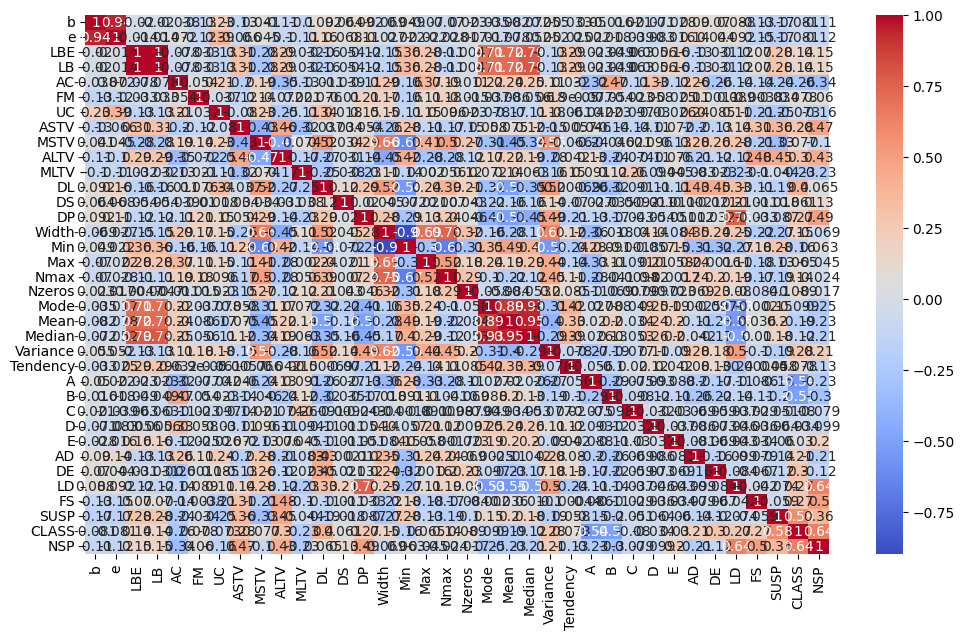

In [78]:
pyplt.figure(figsize=(12, 7))

sbrn.heatmap(df.corr(numeric_only=True),annot=True, cmap="coolwarm")

pyplt.show()

In [57]:
for col in df:
  if (df[col] == 0).all():
     print(f"{col} has only 0 : {(df[col] == 0).all()}")

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
1,Variab10.txt,1996-12-01,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,1996-05-03,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,1996-05-03,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,1996-05-03,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
5,Fmcs_1.txt,1996-05-03,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [86]:
df.drop(columns=['DR', 'FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS'], inplace=True)

KeyError: "['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS'] not found in axis"

In [87]:
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS',
       'DP', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median',
       'Variance', 'Tendency', 'NSP'],
      dtype='str')

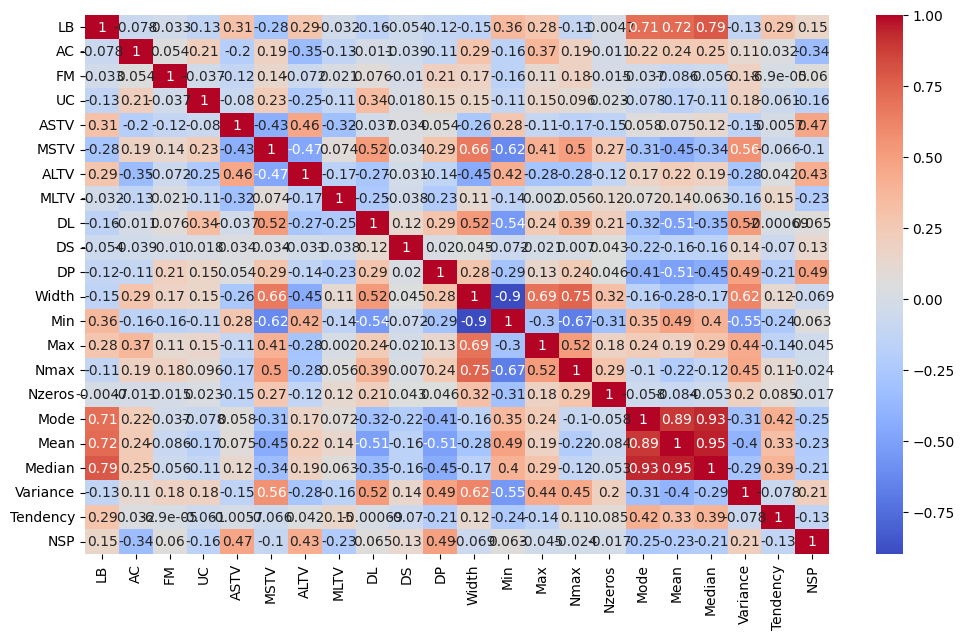

In [88]:
pyplt.figure(figsize=(12, 7))

sbrn.heatmap(df.corr(numeric_only=True),annot=True, cmap="coolwarm")

pyplt.show()

In [92]:
df['NSP'].value_counts()/len(df)

NSP
1.0    0.778457
2.0    0.138758
3.0    0.082785
Name: count, dtype: float64

In [93]:
df.describe()

,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2126.000000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,2.722484,7.241298,3.659925,46.990122,1.332785,9.84666,8.187629,1.570085,0.003293,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,3.560850,37.125309,2.847094,17.192814,0.883241,18.39688,5.628247,2.499229,0.057300,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,0.000000,0.000000,0.000000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,1.000000,32.000000,0.700000,0.00000,4.600000,0.000000,0.000000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,1.000000,0.000000,3.000000,49.000000,1.200000,0.00000,7.400000,0.000000,0.000000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,4.000000,2.000000,5.000000,61.000000,1.700000,11.00000,10.800000,3.000000,0.000000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,26.000000,564.000000,23.000000,87.000000,7.000000,91.00000,50.700000,16.000000,1.000000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


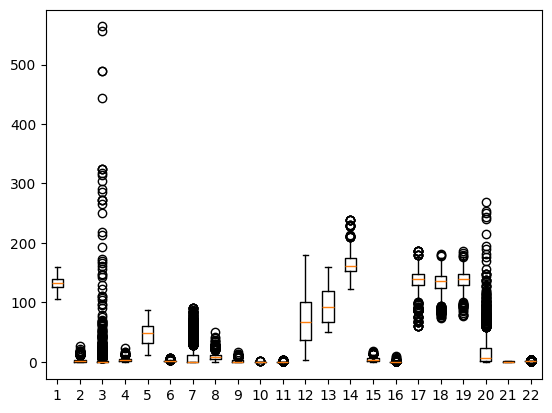

In [104]:
pyplt.boxplot(df)
pyplt.show()

In [120]:
df.skew().sort_values(ascending=False)

DS          17.353457
FM           9.427496
DP           4.235888
Nzeros       3.920287
Variance     3.219974
ALTV         2.195075
NSP          1.849934
DL           1.819119
AC           1.658830
MSTV         1.657339
MLTV         1.331998
Nmax         0.892886
UC           0.835346
Max          0.577862
Width        0.314235
Min          0.115784
LB           0.020312
ASTV        -0.011829
Tendency    -0.311632
Median      -0.478414
Mean        -0.651019
Mode        -0.995178
dtype: float64

In [121]:
df['DS'] = nmpy.log1p(df['DS'])

In [119]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df['DS'] = pt.fit_transform(df[['DS']])

**Train-Test Split: Split the dataset into training and testing sets. The typical ratio for splitting is 80/20 or 70/30, ensuring that the model can be trained on one portion and evaluated on another.**

In [126]:
y=df["NSP"]
x = df.drop(columns=["NSP"])

In [128]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
sm = SMOTE(random_state=42)

# Apply SMOTE to the training data
x_res, y_res = sm.fit_resample(x, y)

print('Original dataset shape %s' % y.value_counts())
print('Resampled dataset shape %s' % y_res.value_counts())

Original dataset shape NSP
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64
Resampled dataset shape NSP
2.0    1655
1.0    1655
3.0    1655
Name: count, dtype: int64


In [133]:
X_train, X_test, Y_train, Y_test = train_test_split(x_res, y_res, test_size=0.2, stratify=y_res, random_state=42)

**Model Training**

In [134]:
from sklearn.linear_model import LogisticRegression

# external configuration variables set by data scientists before training a machine learning model
log_model = LogisticRegression(max_iter=10000)

log_model.fit(X_train, Y_train)

c:\Users\sa250048\OneDrive - Teradata Corporation\Desktop\ml-project\ml-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [135]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [151]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=20)

tree.fit(X_train, Y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [152]:
log_model_y_pred = log_model.predict(X_test)

knn_model_y_pred = knn.predict(X_test)

tree_model_y_pred = tree.predict(X_test)

**Model Evaluation**

In [138]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, log_model_y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8912386706948641


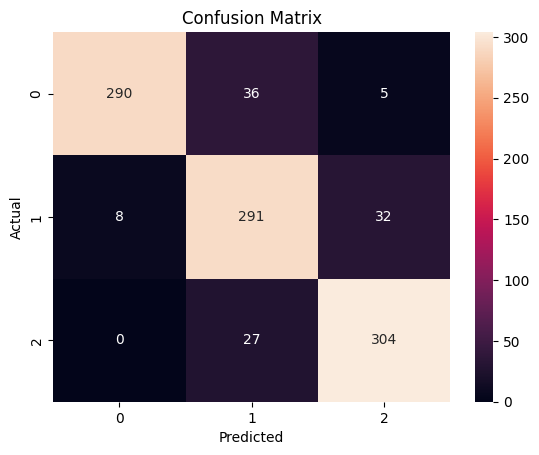

In [140]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, log_model_y_pred)

sbrn.heatmap(cm, annot=True, fmt="d")
pyplt.xlabel("Predicted")
pyplt.ylabel("Actual")
pyplt.title("Confusion Matrix")
pyplt.show()

In [146]:
from sklearn.metrics import precision_score , recall_score, f1_score

precision = precision_score(Y_test, log_model_y_pred, average='weighted')

print("Precision score:", precision)

recall = recall_score(Y_test, log_model_y_pred, average='weighted')

print("recall score:", recall)

f1 = f1_score(Y_test, log_model_y_pred, average='weighted')

print("F1 score:", f1)




Precision score: 0.8955612872980708
recall score: 0.8912386706948641
F1 score: 0.8921651701385492


In [160]:
import json

report = classification_report(Y_test, tree_model_y_pred, output_dict=True)

with open('Log_Regg_classification_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print("Report saved to classification_report.json")

Report saved to classification_report.json


In [147]:
accuracy = accuracy_score(Y_test, knn_model_y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9375629405840886


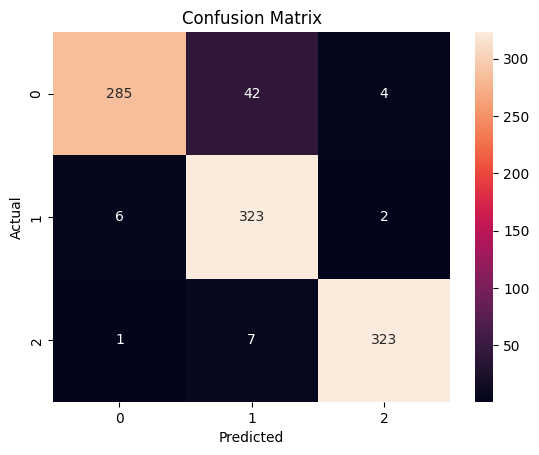

In [148]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, knn_model_y_pred)

sbrn.heatmap(cm, annot=True, fmt="d")
pyplt.xlabel("Predicted")
pyplt.ylabel("Actual")
pyplt.title("Confusion Matrix")
pyplt.show()

In [149]:
precision = precision_score(Y_test, knn_model_y_pred, average='weighted')

print("Precision score:", precision)

recall = recall_score(Y_test, knn_model_y_pred, average='weighted')

print("recall score:", recall)

f1 = f1_score(Y_test, knn_model_y_pred, average='weighted')

print("F1 score:", f1)



Precision score: 0.9420232950286259
recall score: 0.9375629405840886
F1 score: 0.9375448555223836


In [161]:
import json

report = classification_report(Y_test, tree_model_y_pred, output_dict=True)

with open('Knn_classification_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print("Report saved to classification_report.json")

Report saved to classification_report.json


In [153]:
accuracy = accuracy_score(Y_test, tree_model_y_pred)
print("Accuracy:", accuracy)
print("Accuracy:", accuracy)

Accuracy: 0.9033232628398792
Accuracy: 0.9033232628398792


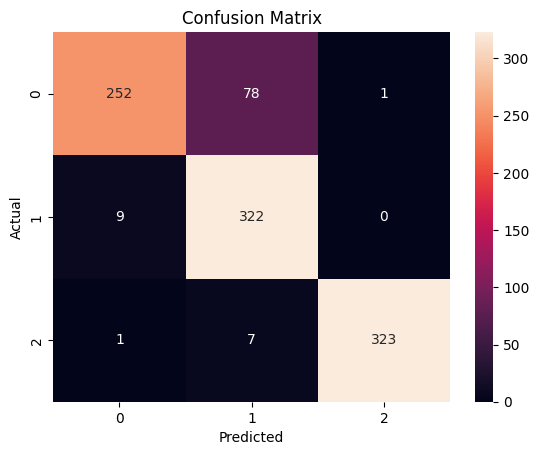

In [155]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, tree_model_y_pred)

sbrn.heatmap(cm, annot=True, fmt="d")
pyplt.xlabel("Predicted")
pyplt.ylabel("Actual")
pyplt.title("Confusion Matrix")
pyplt.show()

In [154]:
from sklearn.metrics import precision_score , recall_score, f1_score

precision = precision_score(Y_test, tree_model_y_pred, average='weighted')

print("Precision score:", precision)

recall = recall_score(Y_test, tree_model_y_pred, average='weighted')

print("recall score:", recall)

f1 = f1_score(Y_test, tree_model_y_pred, average='weighted')

print("F1 score:", f1)


Precision score: 0.9166334774901357
recall score: 0.9033232628398792
F1 score: 0.9029346504133184


In [162]:
import json

report = classification_report(Y_test, tree_model_y_pred, output_dict=True)

with open('tree_classification_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print("Report saved to classification_report.json")



Report saved to classification_report.json


In [164]:
import pickle

pickle.dump(log_model, open('log_model.pkl', 'wb'))
pickle.dump(knn, open('knn_model.pkl', 'wb'))
pickle.dump(tree, open('tree_model.pkl', 'wb'))